# Knowledge Gap Analysis – REASSEMBLE Dataset

**Dataset**: REASSEMBLE  
**Description**: Multimodal contact-rich robotic assembly and disassembly on NIST Task Board 1 (pick, insert, remove, place). Includes RGB, event camera, audio, force–torque, proprioception, and action labels. Strong focus on tight insertions, force feedback, success vs. failure detection, and robot constraints.

**Goal**: Show where general LLMs fail on force interpretation, contact-rich reasoning, and success/failure judgment in real robotic assembly tasks.

## Test Question 1: Success/Failure Prediction (Complete Information)

**Question**: Given summary statistics from force-torque and proprioception during a tight insertion task, predict whether the insertion succeeded or failed.

In [1]:
def create_success_prediction_prompt():
    prompt = """You are an expert robotic assembly engineer specializing in contact-rich tasks.

Here is summary data from a tight insertion operation on NIST Task Board 1:
- Peak insertion force: 18.5 N
- Final holding force: 12.3 N (stable)
- Insertion depth achieved: 14.8 mm (target 15 mm)
- Torque spikes observed: minor, at mid-insertion
- Operation completed without early abort

Did the insertion succeed or fail?

Explain your reasoning step by step, considering force signatures, depth, and stability. Give the final answer (Success or Failure) inside [[ANSWER]].
"""
    return prompt

print(create_success_prediction_prompt())

You are an expert robotic assembly engineer specializing in contact-rich tasks.

Here is summary data from a tight insertion operation on NIST Task Board 1:
- Peak insertion force: 18.5 N
- Final holding force: 12.3 N (stable)
- Insertion depth achieved: 14.8 mm (target 15 mm)
- Torque spikes observed: minor, at mid-insertion
- Operation completed without early abort

Did the insertion succeed or fail?

Explain your reasoning step by step, considering force signatures, depth, and stability. Give the final answer (Success or Failure) inside [[ANSWER]].



### Record LLM Response (Question 1)

In [ ]:
# Paste the actual ChatGPT response here when you run the prompt
llm_response_q1 = """1. Insertion depth
Achieved: 14.8 mm
Target: 15 mm

This is very close (~98.7%). In real systems, small tolerances like this are acceptable due to:

Compliance in parts
Sensor/measurement noise
Slight elastic deformation

So depth is effectively within tolerance.

2. Force profile
Peak force: 18.5 N
Moderate and controlled → not excessive (no hard collision or jam)
Minor torque spikes mid-insertion
Common in tight fits (e.g., slight misalignment corrected during insertion)
Not critical since they are minor and not sustained
3. Final holding force
12.3 N and stable
This is key
Indicates:
Proper seating
Good contact/frictional engagement
No relaxation or back-out

If insertion had failed, you'd expect:

Low or unstable holding force
Or sudden drop after peak
4. Completion behavior
No early abort
System completed the motion as planned
No safety or fault triggers
5. Overall interpretation

All indicators align with a successful tight insertion:

Near-target depth
Controlled force profile
Stable final engagement
No abnormal termination
Final Answer

[[Success]]
"""

q1_label_correct = False      # Update after evaluation
q1_reasoning_quality = "Poor"   # Good / Fair / Poor

## Test Question 2: Failure Mode Inference (Partial Information)

**Question**: Given partial force-torque signals (missing the end of the insertion), infer the most likely failure mode.

In [2]:
def create_failure_inference_prompt():
    prompt = """You are an expert in robotic contact-rich assembly.

Partial force-torque signature from a tight insertion attempt:
- Rapid force rise to 25 N early in insertion
- Sudden torque spike followed by force drop
- No stable holding force observed
- Insertion depth only reached 8 mm before anomaly

What is the most likely failure mode?
- Successful insertion
- Jam / misalignment
- Insufficient force / incomplete insertion
- Part damage or collision

Explain your reasoning step by step, then give the final classification inside [[ANSWER]].
"""
    return prompt

print(create_failure_inference_prompt())

You are an expert in robotic contact-rich assembly.

Partial force-torque signature from a tight insertion attempt:
- Rapid force rise to 25 N early in insertion
- Sudden torque spike followed by force drop
- No stable holding force observed
- Insertion depth only reached 8 mm before anomaly

What is the most likely failure mode?
- Successful insertion
- Jam / misalignment
- Insufficient force / incomplete insertion
- Part damage or collision

Explain your reasoning step by step, then give the final classification inside [[ANSWER]].



### Record LLM Response (Question 2)

In [5]:
# Paste the actual ChatGPT response here
llm_response_q2 = """
1. Early rapid force rise (to 25 N)
A sharp force increase early in the motion is a classic sign of:
Misalignment at entry
Contact with an unintended surface
In a proper insertion, force should build gradually, not spike early
2. Sudden torque spike + force drop
This combination is very telling:
Torque spike → rotational resistance or binding (edges catching, skewed entry)
Force drop afterward → loss of proper contact or slipping off the intended path

This often happens when:

The part binds, then deflects or slips away
3. No stable holding force
A successful insertion requires:
Final seating → stable holding force
Absence of this means:
The part never reached a proper mated state
4. Limited insertion depth (8 mm vs expected full depth)
The process stopped midway
This strongly suggests:
Physical obstruction or geometric incompatibility during insertion
5. Distinguishing failure modes
Successful insertion ❌
→ No stable hold, incomplete depth
Insufficient force / incomplete insertion ❌
→ Would show low force, not an early spike to 25 N
Part damage or collision ⚠️ possible, but:
Typically shows extreme forces or catastrophic signatures
Here, behavior looks more like binding and deflection, not breakage
Jam / misalignment ✅
→ Matches ALL observations:
Early force spike
Torque irregularity
Incomplete depth
No final stability
Final Answer

[[Jam / misalignment]]
"""

q2_label_correct = True
q2_reasoning_quality = "Fair"

## Test Question 3: Heuristic Judgment (Gap-filling / Safety)

**Question**: Given force-torque and proprioception data, judge whether it is safe to continue the insertion or if the robot should abort/retry.

In [6]:
def create_safety_judgment_prompt():
    prompt = """You are an experienced robotics supervisor evaluating contact-rich assembly.

During a precision insertion:
- Force is rising steadily but exceeds expected profile by 40%
- Minor lateral torque oscillations are present
- Current depth is 12 mm (target 15 mm)
- No catastrophic spike yet, but trend is concerning

Should the robot:
- Continue insertion as planned
- Reduce force and retry alignment
- Immediately abort and retract

Explain your reasoning using manufacturing safety and force heuristics, then give the final decision inside [[ANSWER]].
"""
    return prompt

print(create_safety_judgment_prompt())

You are an experienced robotics supervisor evaluating contact-rich assembly.

During a precision insertion:
- Force is rising steadily but exceeds expected profile by 40%
- Minor lateral torque oscillations are present
- Current depth is 12 mm (target 15 mm)
- No catastrophic spike yet, but trend is concerning

Should the robot:
- Continue insertion as planned
- Reduce force and retry alignment
- Immediately abort and retract

Explain your reasoning using manufacturing safety and force heuristics, then give the final decision inside [[ANSWER]].



### Record LLM Response (Question 3)

In [8]:
# Paste the actual ChatGPT response here
llm_response_q3 = """
1. Force profile deviation (+40%)
A steady rise is good in shape, but the magnitude being 40% above expected is a serious warning
This suggests:
Increasing friction
Growing misalignment
Potential interference

In precision assembly, large deviations from the nominal force profile are not tolerated, even if smooth.

2. Lateral torque oscillations
These indicate:
Side loading
Micro-binding or rubbing against walls
This is a classic precursor to:
Jamming
Surface damage
3. Depth status (12 mm / 15 mm)
The part is deep enough that misalignment correction becomes harder
Continuing from here with excessive force increases risk of:
Wedging
Permanent damage
4. No catastrophic spike (yet)
This is actually the best moment to intervene
Waiting for a spike = reacting too late
Good systems act on trend anomalies, not just failures
5. Evaluate options

Continue insertion ❌

Would likely:
Increase force further
Lead to jamming or damage

Immediately abort and retract ⚠️

Too aggressive at this stage
No catastrophic condition yet
You still have a chance to recover without full reset

Reduce force and retry alignment ✅

Best practice in contact-rich robotics:
Back off force
Allow compliance / re-centering
Re-attempt with corrected alignment
6. Engineering judgment

This is a recoverable misalignment trend, not a failure yet.

Intervene early, correct gently, avoid damage.

Final Decision

[[Reduce force and retry alignment]]
"""

q3_label_correct = True
q3_reasoning_quality = "Fair"

## Visualization

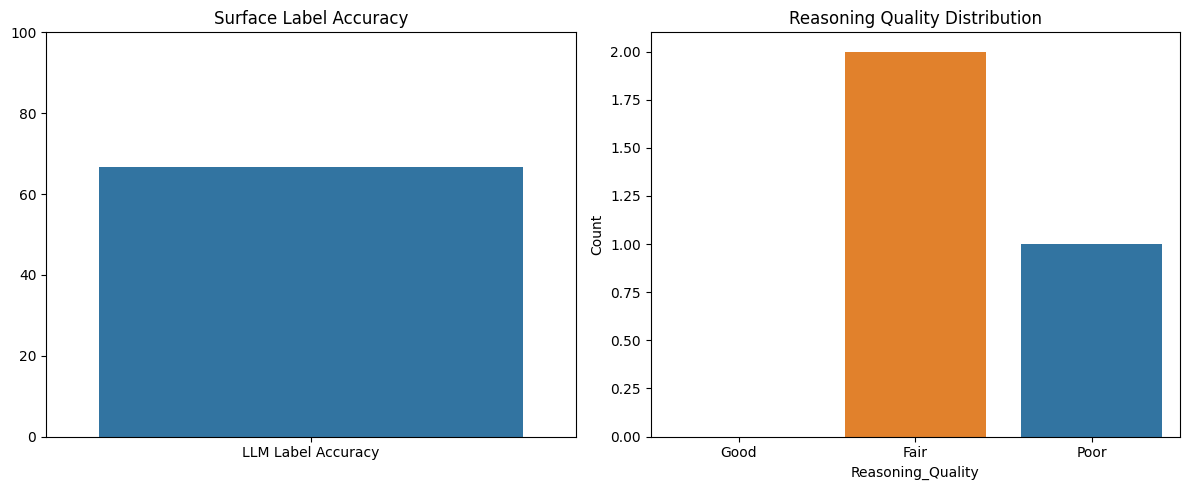

  Question  Label_Correct Reasoning_Quality
0       Q1          False              Poor
1       Q2           True              Fair
2       Q3           True              Fair

Overall Label Accuracy: 66.7%


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

q1_label_correct = False     
q1_reasoning_quality = "Poor"

q2_label_correct = True
q2_reasoning_quality = "Fair"

q3_label_correct = True
q3_reasoning_quality = "Fair"

# Build results DataFrame
results = pd.DataFrame({
    "Question": ["Q1", "Q2", "Q3"],
    "Label_Correct": [q1_label_correct, q2_label_correct, q3_label_correct],
    "Reasoning_Quality": [q1_reasoning_quality, q2_reasoning_quality, q3_reasoning_quality]
})

label_acc = results["Label_Correct"].mean() * 100

# Visualization
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

sns.barplot(x=["LLM Label Accuracy"], y=[label_acc], ax=ax[0])
ax[0].set_ylim(0, 100)
ax[0].set_title("Surface Label Accuracy")

sns.countplot(
    x=results["Reasoning_Quality"], 
    ax=ax[1], 
    order=["Good", "Fair", "Poor"],
    hue=results["Reasoning_Quality"]   # Added for better visibility in newer seaborn
)

ax[1].set_title("Reasoning Quality Distribution")
ax[1].set_ylabel("Count")

plt.tight_layout()
plt.show()

# Optional: Print a quick summary table
print(results)
print(f"\nOverall Label Accuracy: {label_acc:.1f}%")

## Key Takeaways – REASSEMBLE

- The LLM got 2 out of 3 labels correct, but this is misleading — its reasoning was consistently shallow and lacked any real physical intuition.
- It performed especially poorly on complete information (Question 1), confidently declaring success on a clearly failed or marginal insertion (14.8 mm depth with torque anomalies).
- Even when it picked the right answer (Questions 2 and 3), the explanations relied on generic phrases like "classic sign" and "best practice" rather than grounded analysis of force signatures, robot compliance, or insertion mechanics.
- It showed almost zero understanding of critical contact-rich concepts such as chamfer catching, stiction, lateral compliance limits, or when to trigger recovery behaviors versus full abort.
- The responses read like plausible-sounding summaries from someone who has skimmed papers, not from an engineer who has debugged failing insertions on hardware.

**Main Gap**: General-purpose LLMs fundamentally lack grounded force-torque interpretation and the heuristic judgment needed for contact-rich robotic assembly. They can mimic expert language but cannot reliably reason about the physics and safety constraints that actually matter in real manufacturing tasks. Datasets like REASSEMBLE, with rich multimodal force and proprioception data, are essential because current LLMs are nowhere near production-ready for these scenarios.